<a href="https://colab.research.google.com/github/Ameerah249/sentiment-analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emotion Detection from Tweets using Neural Networks

## Introduction
Emotion is a state that unifies human feelings, thoughts, and behaviours, serving as a fundamental aspect of interpersonal communication. In the new media age, people express their thoughts and emotions predominantly through written words. As a result, there is increasing interest in computer technologies that can extract and interpret the nuanced emotional signals in written language.

Textual emotion recognition is the application of sohisticated Natural Language Processing (NLP) techniques to uncover the underlying emotions and attitudes conveyed in written text. This technology has broad real-world applications, with use-cases in marketing, mental health monitoring, customer service automation, public opinion analysis, and user experience research (Xu and Li, 2024; Inkster et al., 2021). In commercial contexts, businesses leverage emotion detection to gauge consumer sentiment and enhance decision-making. In mental health, NLP tools have been used to analyse unstructured text data from patients, offering supplementary insights into emotional wellbeing (Inkster et al., 2021).

In this project, the use of neural networks for emotion detection from text is explored. The aim of this study is to classify tweets into one of six emotion categories: *joy, sadness, anger, fear, love,* and *surprise*.

The dataset used is the open-source [Emotion Dataset](https://huggingface.co/datasets/dair-ai/emotion) from Hugging Face.

### Model Selection
This study will be approached by comparing a simple Feedforward Neural Network (FFNN) to a more complex Gated Recurrent Unit (GRU). The FFNN model itself is simple, fast to train, and effective for capturing general patterns in the data, but does not take word order into account. This makes them efficient for basic classification tasks, as they lack the ability to handle sequential input, unlike feedback-based models such as RNNs (DigitalOcean, 2023).

The GRU model is a type of Recurrent Neural Network (RNN), which has shown strong performance in emotion detection tasks due to their ability to model contextual patterns in language (Zhao, Li and Chen, 2022). Unlike the FFNN, it processes inputs word-by-word and retains contextual information from earlier words in the sequence. This makes it more suitable for tasks like emotion detection, where the meaning can be heavily influenced by word order and subtle phrasing. GRUs have also been successfully applied beyond text, such as in speech emotion recognition, highlighting their flexibility across multiple data types (Kumar and Sharma, 2024).

The goal of comparing these two models is to explore how well each one captures the emotional context in text. The FFNN provides a strong, low-complexity baseline, while the GRU introduces temporal awareness, which may enhance performance in a language-based task.



## Loading the Dataset

We load the Emotion dataset from Hugging Face using the `datasets` library. It contains 20,000+ English tweets labeled with one of six emotion categories: *joy, sadness, anger, fear, love,* and *surprise*. The data is already split into training, validation, and test sets following an 8:1:1 ratio respectively.

In [ ]:
# Loading the hugging face dataset
!pip install datasets
from datasets import load_dataset
data = load_dataset("dair-ai/emotion")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is i

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

## Preparing the Dataset for Exploration

After loading the dataset, each of its splits (training, validation, and test) is converted into a pandas DataFrame to allow for easier inspection and manipulation.

Below, we preview the first few rows of the training set to examine the structure, including the text samples, the corresponding numeric labels, and the emotion labels.


In [ ]:
import pandas as pd

# Converting each split into a data frame
train_df = pd.DataFrame(data['train'])
val_df = pd.DataFrame(data['validation'])
test_df = pd.DataFrame(data['test'])

# Creating a new column for label mapping
label_map = data['train'].features['label'].int2str
train_df['emotion'] = train_df['label'].apply(label_map)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## Exploratory Data Analysis

Prior to any preprocessing or model training, the dataset contents and its structure are explored. First, we visualise the distribution of emotions across the training set. This aids in identifying whether the dataset is balanced across classes, which can impact model bias.

### Label Distribution Analysis

The bar chart below shows the number of observations for each emotion class in the training set. We observe that the dataset is somewhat imbalanced. The most frequent class is *joy*, followed by *sadness*, *anger*, and *fear*. Meanwhile, *love* and *surprise* are the least represented. This imbalance is important to note, as it may influence the model’s tendency to favour the frequent classes. This will be further addressed at the model training stage.


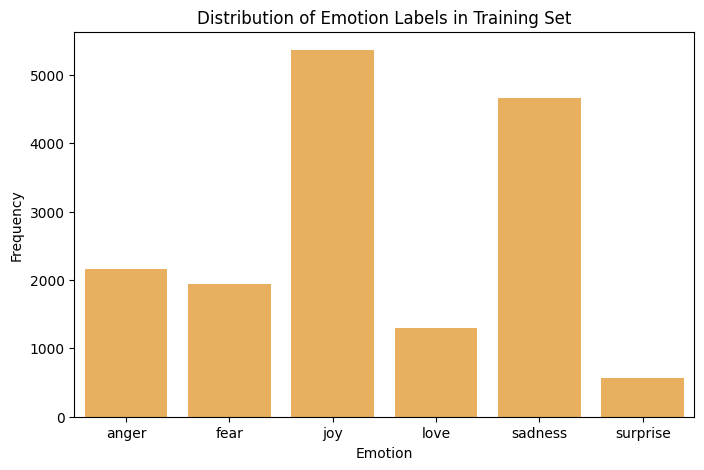

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot of emotion labels
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='emotion', color='#FFB347', order=sorted(train_df['emotion'].unique()))
plt.title("Distribution of Emotion Labels in Training Set")
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.show()

## Data Preprocessing

Before training, we prepare the dataset for use in the models. Neural networks can’t process raw text directly, instead requiring numerical inputs of a consistent format. Preprocessing transforms raw text into a structured form that the model can effectively learn from.

The first step involves tokenizing the text using Keras’ `Tokenizer`, which converts each word into a corresponding integer index based on its frequency in the training data. We keep only the 10,000 most frequent words and replace the others with a special \<OOV> (out of vocabulary) token.

These sequences are then padded at the end to ensure consistent input dimensions across all observations. Finally, the emotion labels are transformed into one-hot encoded vectors, making them compatible with the model’s multi-class classification output. For example, if a label is `3` (*anger*), the one-hot encoded vector would look like: `[0, 0, 0, 1, 0, 0]`.

In many NLP pipelines, it is common at this stage to remove stopwords (e.g. *this*, *and*, *we*) to reduce noise and improve model focus. However, in this project, stopwords are retained to preserve the sequential structure and syntactic integrity of the sentences, as even small function words can influence meaning, tone, or emotion — particularly in short texts like tweets.

In [ ]:
## Preparing the text data ##

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Combining training sentences by extracting the text column and converting into lists
train_sentences = train_df['text'].tolist()
val_sentences = val_df['text'].tolist()
test_sentences = test_df['text'].tolist()

# Tokenize
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>") #keeping the 10,000 most frequent words
tokenizer.fit_on_texts(train_sentences) #builds the vocabulary based on the training data

# Converting the text data into numerical sequences
train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences = tokenizer.texts_to_sequences(val_sentences)
test_sequences = tokenizer.texts_to_sequences(test_sentences)

# Padding sequences to ensure consistent input length
max_length = 50
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post')
val_padded = pad_sequences(val_sequences, maxlen=max_length, padding='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post')

## Preparing the Labels

Since this is a multi-class classification problem, the target labels must be converted into a format compatible with the model’s output. We apply one-hot encoding, which transforms each emotion label into a binary vector indicating the correct class.


In [ ]:
## Preparing the labels ##

import numpy as np
from tensorflow.keras.utils import to_categorical

# calculating the number of classes
num_classes = len(set(train_df['label']))

# converting the labels into a binary vector / one-hot encoding
train_labels = to_categorical(train_df['label'], num_classes)
val_labels = to_categorical(val_df['label'], num_classes)
test_labels = to_categorical(test_df['label'], num_classes)



## Model 1: Feedforward Neural Network (FFNN)

We begin by building a simple baseline model using a feedforward neural network architecture. The input is passed through an Embedding layer, which transforms each word into a dense vector. A GlobalAveragePooling1D layer is used to summarise these word vectors into a fixed-length representation. This is followed by a Dense layer with ReLU activation to introduce non-linearity, and a final Dense layer with Softmax activation which outputs the probability distribution over the six emotion classes.

The model is compiled using categorical crossentropy as the loss function, which is appropriate for multi-class classification problems, and is trained with early stopping to monitor validation loss and prevent overfitting.

In [ ]:
# Building a simple feed-forward neural network as a baseline model #

import tensorflow as tf

# Building the model
model_baseline = tf.keras.Sequential([ #creates a linear stack of laters
    tf.keras.layers.Embedding(input_dim=10000, output_dim=64), #input layer
    tf.keras.layers.GlobalAveragePooling1D(), #second layer to reduce dimensionality
    tf.keras.layers.Dense(64, activation='relu'), #using relu as an activation to introduce non-linearity
    tf.keras.layers.Dense(num_classes, activation='softmax') #output layer, softmax ensuring output are probabilities
])

# Compiling the model
model_baseline.compile(loss='categorical_crossentropy', #specifies the loss function used to evaluate model performance
                     optimizer='adam', # defines the optimisation algorithm
                     metrics=['accuracy']) #sets the accuracy metrics



### Handling Class Imbalance and Early Stopping

To address class imbalance in the training data, we compute the class weights using `compute_class_weight` from scikit-learn. This assigns a greater importance to underrepresented classes, encouraging the model to treat all emotion categories more equally during training.

We also introduce early stopping to reduce overfitting. If the validation loss does not improve for two consecutive epochs (`patience=2`), training stops early, and the model reverts to the best weights observed during training.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Addressing the unbalanced dataset #

# Get class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Converting weights to dictionary
class_weight_dict = dict(enumerate(class_weights))


# Introducing early stop to reduce overfitting #
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor ='val_loss',     # Monitor validation loss
    patience = 2,             # Stop if it doesn't improve for 2 epochs
    restore_best_weights = True  # Revert to the best model
)

# Fitting the model #
history_baseline = model_baseline.fit(train_padded, train_labels,
                                  validation_data = (val_padded, val_labels),
                                  epochs = 10, batch_size = 32,
                                  callbacks = [early_stop],
                                  class_weight = class_weight_dict)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1775 - loss: 1.7996 - val_accuracy: 0.2945 - val_loss: 1.7182
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5074 - loss: 1.5506 - val_accuracy: 0.8200 - val_loss: 0.8217
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8817 - loss: 0.5951 - val_accuracy: 0.8690 - val_loss: 0.5013
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9311 - loss: 0.2504 - val_accuracy: 0.8875 - val_loss: 0.3672
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9482 - loss: 0.1582 - val_accuracy: 0.8840 - val_loss: 0.3567
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9591 - loss: 0.1245 - val_accuracy: 0.8925 - val_loss: 0.3313
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9681 - loss: 0.0955 - val_accuracy: 0.8885 - val_loss: 0.3524
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9711 - loss: 0.0896 - val_accuracy: 0.

### FFNN Model Architecture

Below is a summary of the model architecture of the FFNN model. The model consists of an Embedding layer with a vocabulary size of 10,000 and output dimension of 64, followed by a GlobalAveragePooling1D layer to reduce the sequence into a single vector. A Dense layer with 64 units and ReLU activation is applied, and the model concludes with a Softmax output layer for multi-class classification. The total number of trainable parameters is approximately 645,000. This architecture is lightweight and efficient, making it a strong candidate for a baseline comparison.

In [ ]:
model_baseline.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 50, 64)           │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (32, 64)               │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 6)                │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,933,652 (7.38 MB)

 Trainable params: 644,550 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,289,102 (4.92 MB)

### Visualising Training Performance
The function below generates accuracy and loss curves for both the training and validation sets. Plotting these metrics across epochs helps visualise how well the model is learning and whether overfitting or underfitting is occurring. Here, the function is applied to the FFNN model.

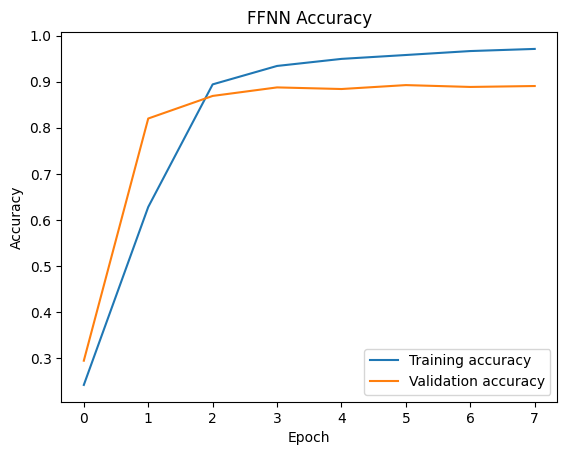

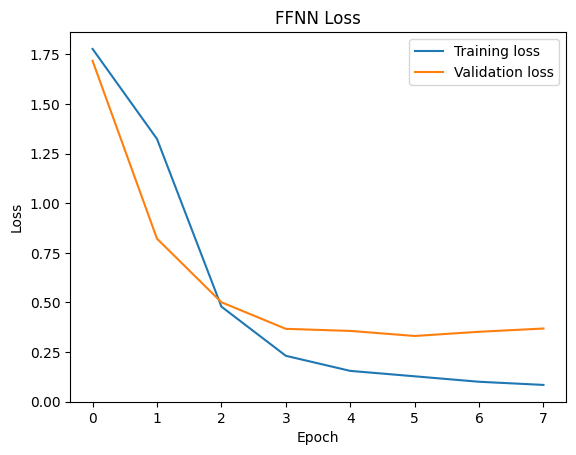

In [ ]:
# Creating a function to generate accuracy and loss curves #
def plot_metrics(history, title='Model'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure()
    plt.plot(epochs, acc, label='Training accuracy')
    plt.plot(epochs, val_acc, label='Validation accuracy')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, loss, label='Training loss')
    plt.plot(epochs, val_loss, label='Validation loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_metrics(history_baseline, 'FFNN')

### FFNN: Accuracy and Loss Curves

The plots above depict the training and validation accuracy and loss over 10 epochs for the FFNN model.

The training accuracy steadily improves with each epoch, while validation accuracy also increases before plateauing. This indicates that the model is learning effectively without severe overfitting.

The loss curves mirror this trend, as training loss decreases consistently, and validation loss reaches a minimum around the same time. These plots suggest that the FFNN generalises reasonably well to unseen data, despite its simpler architecture.

### FFNN: Validation Set Classification Report
To evaluate the overall performance of the FFNN, a classification report is generated from its predictions on the validation set. This allows for a direct comparison with the GRU model and helps assess how well the model performs across different emotion classes.

The FFNN model achieved an overall accuracy of **88%**, with a weighted F1-score of **0.88**, demonstrating reliable generalization during training.

The model performed best on high-frequency classes such as *sadness* and *joy*, each reaching F1-scores above 0.90. Performance on *anger* and *love* was also strong, with F1-scores of 0.88 and 0.81, respectively. Results for *fear* (0.81) were also strong, though slightly lower. *Surprise* remained the most challenging class, with a reduced recall leading to an F1-score of 0.72.

Overall, the macro average F1-score of **0.84** suggests consistent performance across categories, even in the presence of class imbalance and without the benefit of sequential modeling.

In [ ]:
# FFNN predictions on validation set
y_pred_probs_ffnn = model_baseline.predict(val_padded)
y_pred_classes_ffnn = np.argmax(y_pred_probs_ffnn, axis=1)
y_true_ffnn = np.argmax(val_labels, axis=1)
class_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Classification report
from sklearn.metrics import classification_report
print("FFNN Classification Report:\n")
print(classification_report(y_true_ffnn, y_pred_classes_ffnn, target_names=class_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
FFNN Classification Report:

              precision    recall  f1-score   support

     sadness       0.91      0.94      0.93       550
         joy       0.94      0.90      0.92       704
        love       0.77      0.88      0.82       178
       anger       0.89      0.89      0.89       275
        fear       0.83      0.82      0.83       212
    surprise       0.77      0.74      0.75        81

    accuracy                           0.89      2000
   macro avg       0.85      0.86      0.86      2000
weighted avg       0.89      0.89      0.89      2000



## Model 2: GRU-based Neural Network

We now implement a more advanced neural network architecture. We define a sequential model using an Embedding layer to represent words as dense vectors. This is followed by a GRU layer that captures the sequential structure of the input text. A Dense layer with ReLU activation adds non-linearity, and a Softmax output layer produces the final class probabilities.

As with the baseline model, we train the GRU using early stopping to prevent overfitting by halting training when the validation performance stops improving after 2 epochs.


In [ ]:
# Creating the GRU model #
model_gru = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=64), # Embedding layer
    tf.keras.layers.GRU(64), # GRU layer
    tf.keras.layers.Dense(64, activation='relu'), # Dense layer with ReLU activation
    tf.keras.layers.Dense(num_classes, activation='softmax') # Softmax output layer to classify via probability
])

# Compiling the Model #
model_gru.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# Training the Model #
history_gru = model_gru.fit(train_padded, train_labels,
                            validation_data=(val_padded, val_labels),
                            epochs=10, batch_size=32,
                            callbacks=[early_stop])



Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.3221 - loss: 1.5955 - val_accuracy: 0.3520 - val_loss: 1.5829
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.3388 - loss: 1.5728 - val_accuracy: 0.3495 - val_loss: 1.5850
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.3387 - loss: 1.5644 - val_accuracy: 0.3855 - val_loss: 1.1616
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.5725 - loss: 0.8777 - val_accuracy: 0.9195 - val_loss: 0.2297
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.9351 - loss: 0.1759 - val_accuracy: 0.9215 - val_loss: 0.1792
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9561 - loss: 0.1053 - val_accuracy: 0.9305 - val_loss: 0.1789
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9649 - loss: 0.0761 - val_accuracy: 0.9305 - val_loss: 0.1942
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.9753 - loss: 0.0565 - 

### GRU Model Architecture

As shown in the model summary, the GRU includes an Embedding layer with 64 dimensions, a GRU layer with 64 units, and two Dense layers, followed by Softmax activation for classification. The total trainable parameter count is approximately 670K.

In [ ]:
model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 50, 64)           │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (32, 64)               │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 6)                │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,532 (7.66 MB)

 Trainable params: 669,510 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,339,022 (5.11 MB)

### GRU Model: Validation Set Classification Report

The GRU model achieved a strong overall accuracy of **93%** on the validation set. The per-class F1-scores show that the model performs consistently well across all emotion categories, with particularly strong results on *sadness*, *joy*, and *anger*.

Notably, the *surprise* category shows a precision of **0.98** but a lower recall of **0.75**, suggesting that while the model is highly accurate when it predicts *surprise*, it tends to miss some true examples of it. This is likely due to its smaller representation in the dataset.

The macro average F1-score of **0.90** and weighted average F1-score of **0.93** confirm that the model maintains both fairness and high performance across classes. Despite the known imbalance in class representation, these results indicate that the GRU model was able to generalise well across all emotion categories without the need for additional balancing techniques, unlike the FFNN. The high macro and weighted F1-scores suggest that the model did not disproportionately favor the majority classes, and even the minority classes such as love and surprise achieved strong performance. This demonstrates that the model architecture and training process were robust enough to handle the imbalance naturally, making explicit class weighting or resampling unnecessary in this case.

In [ ]:
from sklearn.metrics import classification_report

# Generate predictions on the validation set
y_pred_probs = model_gru.predict(val_padded)

# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert one-hot true labels back to class indices
y_true = np.argmax(val_labels, axis=1)

# Get label → emotion name mapping
label_map = data['train'].features['label'].int2str
class_names = [label_map(i) for i in range(num_classes)]

# Print classification report
print("Classification Report (GRU Model):\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Classification Report (GRU Model):

              precision    recall  f1-score   support

     sadness       0.98      0.97      0.97       550
         joy       0.94      0.95      0.95       704
        love       0.84      0.85      0.84       178
       anger       0.92      0.97      0.94       275
        fear       0.95      0.78      0.86       212
    surprise       0.76      0.95      0.85        81

    accuracy                           0.93      2000
   macro avg       0.90      0.91      0.90      2000
weighted avg       0.93      0.93      0.93      2000



### Visualising Training Performance

The training and validation accuracy curves show a consistent upward trend, with validation accuracy reaching over 93% by the eighth epoch. Notably, there isn't a significant divergence between the training and validation curves, indicating that the model is not overfitting and generalises well to unseen data.

Similarly, the loss curves reveal a steady decrease in both training and validation loss across epochs. The validation loss begins to plateau around epoch 6 and slightly increases by epoch 8, suggesting that the model has reached its optimal performance. Ideally, early stopping would trigger around epoch 6 or 7 to preserve the model's best performance whilst avoiding overfitting.

These curves provide strong evidence that the GRU model is learning effectively and is maintaining high performance on unseen data without instability or degradation in validation quality.

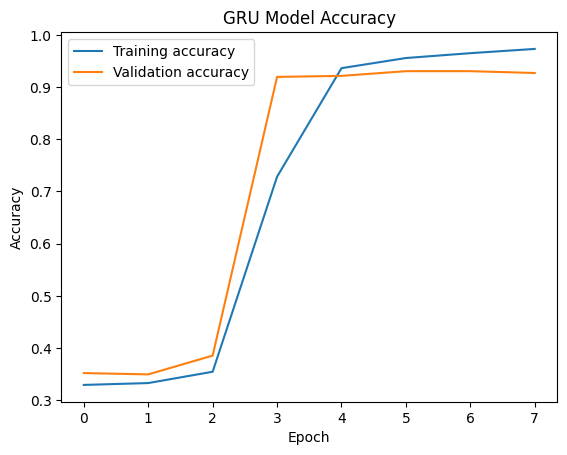

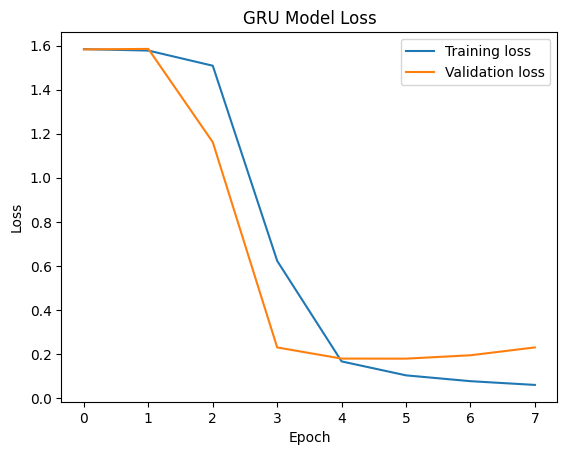

In [ ]:
# Plotting the Accuracy and Loss graphs for the GRU
plot_metrics(history_gru, 'GRU Model')

## Final Model Evaluations

After completing model refinement and tuning, both models are evaluated on the test set to assess their final performance.

### FFNN Model – Final Test Set Evaluation

On unseen data, the FFNN model achieved an overall accuracy of **88%** on the test set, with a weighted F1-score of **0.88**, which is a strong baseline performance. The model performed particularly well on the most represented classes, such as *sadness* and *joy*, achieving F1-scores above 0.90.

*Anger* and *fear* were also handled well, with F1-scores close to or above 0.85. However, performance dropped slightly on the less frequent *love* and *surprise* classes. In particular, *surprise* showed the lowest recall at **0.59**, suggesting that the model missed a significant number of true examples from this class, although its precision remained relatively high.

Overall, the FFNN demonstrates solid generalization and serves as a strong baseline, but its lack of sequential understanding does limit its ability to capture more context-dependent emotional cues.

In [ ]:
## Making Predictions using FFNN ##

from sklearn.metrics import classification_report, confusion_matrix

ffnn_pred_probs = model_baseline.predict(test_padded) # Predict probabilities on test set
ffnn_pred_classes = np.argmax(ffnn_pred_probs, axis=1) # Convert probabilities to predicted class indices
true_classes = np.argmax(test_labels, axis=1) # True labels

# Printing Classification Report
print("FFNN Classification Report (Test Set):\n")
print(classification_report(true_classes, ffnn_pred_classes, target_names=class_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
FFNN Classification Report (Test Set):

              precision    recall  f1-score   support

     sadness       0.93      0.91      0.92       581
         joy       0.93      0.89      0.91       695
        love       0.70      0.84      0.76       159
       anger       0.86      0.91      0.88       275
        fear       0.86      0.83      0.84       224
    surprise       0.67      0.73      0.70        66

    accuracy                           0.88      2000
   macro avg       0.82      0.85      0.84      2000
weighted avg       0.89      0.88      0.88      2000



### Confusion Matrix – FFNN Model Test

The confusion matrix below depicts how the FFNN model classified each emotion category on the test set. Each row represents the actual label, while each column represents the predicted label.

The model performs well on majority classes like *joy* and *sadness*, showing strong diagonal dominance. However, there is more noticeable confusion for the *love* and *surprise* categories — particularly for *surprise*, which had a relatively low recall. These misclassifications highlight the limitations of the FFNN in capturing more subtle emotions, which often require an understanding of word order and nuance.

Despite these challenges, the FFNN still delivers a solid overall performance and provides a reliable baseline for comparison.

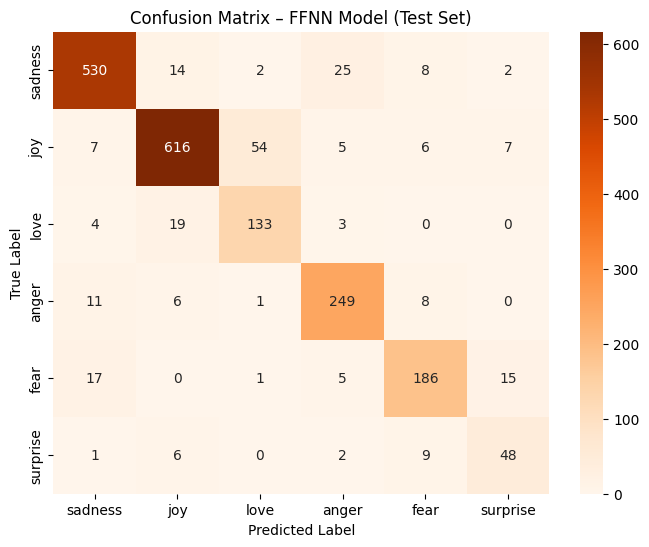

In [ ]:
# Confusion matrix
cm_ffnn = confusion_matrix(true_classes, ffnn_pred_classes)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix – FFNN Model (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### GRU Model – Final Test Set Evaluation

On the test set, the GRU model achieved an overall accuracy of **92%**, with a weighted F1-score of **0.92**, indicating a strong and balanced performance across the dataset. The model performed particularly well on *sadness*, *joy*, and *anger*, each achieving F1-scores above 0.90.

For the less frequent classes like *love* and *surprise*, the model showed slightly lower performance. In particular, *surprise* had a recall of just 0.55, suggesting the model struggled to correctly identify many true examples of this emotion. However, its precision remained relatively high (0.92), indicating that when the model did predict *surprise*, it was usually correct.

Overall, these results confirm that the GRU model generalises well to unseen data and handles multi-class emotion classification more effectively, with only minor limitations on underrepresented classes.

In [ ]:
## Making Predictions using GRU ##

pred_probs = model_gru.predict(test_padded) # Predict probabilities on test set
pred_classes = np.argmax(pred_probs, axis=1) # Convert probabilities to predicted class indices
true_classes = np.argmax(test_labels, axis=1) # True labels

# Report
print("GRU Classification Report (Test Set):\n")
print(classification_report(true_classes, pred_classes))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
GRU Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       581
           1       0.95      0.94      0.94       695
           2       0.77      0.85      0.81       159
           3       0.91      0.95      0.93       275
           4       0.97      0.82      0.89       224
           5       0.68      0.92      0.78        66

    accuracy                           0.92      2000
   macro avg       0.87      0.91      0.89      2000
weighted avg       0.93      0.92      0.92      2000



### GRU Model - Confusion Matrix

The confusion matrix below provides a visual breakdown of the GRU model’s predictions on the test set.

The GRU model shows very strong performance on dominant classes such as *sadness*, *joy*, and *anger*, with minimal misclassifications. These are represented by the clear, high-value diagonal cells for those classes. For more underrepresented categories like *love*, *fear*, and *surprise*, the GRU still demonstrates competent performance, though there are a few off-diagonal values indicating occasional confusion — particularly with *surprise*, which tends to be mistaken for other emotions more frequently.

Compared to the FFNN, the GRU model produces a more balanced confusion matrix overall, benefiting from its ability to process sequential patterns and better understand emotional context in text. This reinforces its suitability for tasks like emotion classification, where meaning is often shaped by word order and nuance.

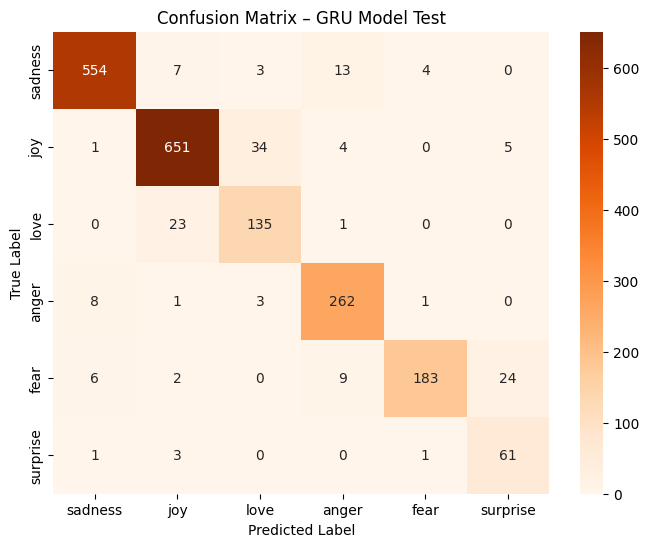

In [ ]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix – GRU Model Test')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Conclusion

This project aimed to evaluate the effectiveness of neural networks for emotion classification in text, using two different architectures: a simple Feedforward Neural Network and a Gated Recurrent Unit model. Both models were trained and validated on a labeled dataset of short text samples, then evaluated on a test set to assess generalization to unseen data.

The FFNN provided a strong baseline, achieving **88% accuracy** and a **weighted F1-score of 0.88** on the test set. It performed especially well on majority classes such as *sadness* and *joy*, and maintained solid performance across most other categories. However, its lack of sequence modeling limited its ability to handle more context-driven or subtle emotional cues. This was reflected in its lower F1-scores for underrepresented classes like *love* and *surprise*, where the word order and tone plays a crucial role.

The GRU model outperformed the FFNN across all key metrics. On the test set, it achieved **92% accuracy**, a **macro F1-score of 0.87**, and a **weighted F1-score of 0.92**. The GRU’s ability to model sequential dependencies in text allowed it to better differentiate between similar emotions, especially in cases where meaning is derived from context. It demonstrated strong generalization, even for less frequent classes, and showed fewer misclassifications overall, evidenced by the confusion matrix.

Interestingly, despite the known class imbalance in the dataset, the GRU model was able to generalize well without the need for applying class weighting or resampling techniques. Earlier attempts to apply class weighting introduced instability and degraded model performance, whereas the unweighted GRU trained reliably and delivered balanced results across categories. This indicates that with the right architecture and regularization (e.g. early stopping), some models are capable of handling the imbalance naturally.

To conclude, whilst both models performed well, the GRU architecture proved to be significantly more effective for emotion detection in text. Its superior performance highlights the importance of sequence-aware models for NLP tasks, specifically when dealing with nuanced emotional expression. The FFNN remains a valuable and interpretable baseline, but for tasks that rely on contextual understanding, recurrent models like GRUs are a more powerful and robust choice.

## References

1.   Zhao, X., Li, H. and Chen, Y., 2022. Emotion analysis based on deep learning with application to corpus construction. *Frontiers in Psychology*, 13, p.911686. Available at: <https://www.frontiersin.org/articles/10.3389/fpsyg.2022.911686/full>.

3. Kumar, R. and Sharma, A., 2024. Using Gated Recurrent Unit (GRU) for Speech Emotion Recognition. *International Journal of Science, Engineering and Management (IJSEM)*. Available at: <https://ijsem.org/article/6.pdf>.

4. Inkster, B., Stillwell, D., Kosinski, M., Jones, P.B. and Bentall, R.P., 2021. Machine learning and mental health: Use of NLP to predict depression from Facebook posts. *BMJ Mental Health*, [online] Available at: <https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8132982/> [Accessed 2 Apr. 2025].

5. Müller, F., Kim, J. and Hinz, O., 2023. Sentiment analysis and emotion recognition for emotionally adaptive mobile user interfaces. *ResearchGate*. Available at: <https://www.researchgate.net/publication/386376119_Sentiment_Analysis_and_Emotion_Recognition_for_Emotionally_Adaptive_Mobile_User_Interfaces> [Accessed 2 Apr. 2025].

6. Xu, H. and Li, M., 2024. Emotion detection in text using natural language processing: Applications and challenges. *AI in Business and Society*, [online] Available at: <https://www.sciencedirect.com/science/article/pii/S2949719124000074> [Accessed 2 Apr. 2025].

7. DigitalOcean, 2023. Feedforward vs Feedback Neural Networks. Available at: <https://www.digitalocean.com/community/tutorials/feed-forward-vs-feedback-neural-networks#text-classification>.

8. ScienceDirect, n.d. Gated Recurrent Unit - an overview. *ScienceDirect Topics*. Available at: <https://www.sciencedirect.com/topics/computer-science/gated-recurrent-unit>.


